# Day 1 — Exploratory Data Analysis Deep Dive

## Task Overview

In this notebook, I will perform a deeper exploratory data analysis on the e-commerce dataset. The goal is to understand business patterns, analyze sales, products, and customers, and create visualizations that help explain the data clearly.

This task focuses on turning data into useful business insights before building an analytics dashboard.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Chart style
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [2]:
%pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.3 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.3 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.3 MB 1.8 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.3 MB 2.1 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.3 MB 2.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 2.5 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 2.5 MB/s eta 0:00:03
   -------------------- ------------------- 4.7/9.3 MB 2.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.3 MB 2.8 


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
c:\Users\homam\OneDrive\Desktop\intern-bootcamp\05_analytics

Files and folders here:
['eda_analysis.ipynb', 'eda_deepdive.ipynb', 'eda_summary.md', 'mini_project.ipynb', 'mini_project_report.md', 'README.md']


In [5]:
print("Files in data/raw:")
print(os.listdir("data/raw"))

print("\nFiles in data/processed:")
print(os.listdir("data/processed"))

Files in data/raw:


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw'

In [6]:
print("Files in ../data/raw:")
print(os.listdir("../data/raw"))

print("\nFiles in ../data/processed:")
print(os.listdir("../data/processed"))

Files in ../data/raw:
['customers.csv', 'orders.csv', 'order_items.csv', 'products.csv', 'transactions.csv']

Files in ../data/processed:
['customers_clean.parquet', 'features.csv', 'features_large.csv', 'logs', 'orders_clean.parquet', 'order_items_clean.parquet', 'products_clean.parquet', 'transactions_clean.parquet']


In [9]:
customers = pd.read_parquet("../data/processed/customers_clean.parquet")
orders = pd.read_parquet("../data/processed/orders_clean.parquet")
order_items = pd.read_parquet("../data/processed/order_items_clean.parquet")
products = pd.read_parquet("../data/processed/products_clean.parquet")
transactions = pd.read_parquet("../data/processed/transactions_clean.parquet")

print("Cleaned data loaded successfully.")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Transactions:", transactions.shape)

ArrowKeyError: No type extension with name arrow.py_extension_type found

In [8]:
%pip install pyarrow

   ---------------------------------------- 0.0/27.4 MB ? eta -:--:--
   --- ------------------------------------ 2.1/27.4 MB 23.5 MB/s eta 0:00:02
   ---------- ----------------------------- 7.3/27.4 MB 25.2 MB/s eta 0:00:01
   -------------------- ------------------- 13.9/27.4 MB 26.4 MB/s eta 0:00:01
   ----------------------- ---------------- 16.3/27.4 MB 23.2 MB/s eta 0:00:01
   --------------------------- ------------ 19.1/27.4 MB 20.1 MB/s eta 0:00:01
   ------------------------------ --------- 20.7/27.4 MB 18.2 MB/s eta 0:00:01
   --------------------------------- ------ 22.8/27.4 MB 16.4 MB/s eta 0:00:01
   ------------------------------------ --- 24.9/27.4 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------  27.3/27.4 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 27.4/27.4 MB 14.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
customers = pd.read_csv("../data/raw/customers.csv")
orders = pd.read_csv("../data/raw/orders.csv")
order_items = pd.read_csv("../data/raw/order_items.csv")
products = pd.read_csv("../data/raw/products.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")

print("CSV data loaded successfully.")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Transactions:", transactions.shape)

CSV data loaded successfully.
Customers: (100, 5)
Orders: (200, 4)
Order Items: (496, 6)
Products: (30, 4)
Transactions: (200, 6)


In [11]:
print("Customers columns:")
print(customers.columns)
display(customers.head())

print("Orders columns:")
print(orders.columns)
display(orders.head())

print("Order Items columns:")
print(order_items.columns)
display(order_items.head())

print("Products columns:")
print(products.columns)
display(products.head())

print("Transactions columns:")
print(transactions.columns)
display(transactions.head())

Customers columns:
Index(['customer_id', 'first_name', 'email', 'city', 'signup_date'], dtype='str')


,customer_id,first_name,email,city,signup_date
0,1,Customer1,customer1@example.com,Abu Dhabi,2025-09-22 17:14:47.542946
1,2,Customer2,customer2@example.com,Ajman,2025-11-21 17:14:47.542968
2,3,Customer3,customer3@example.com,Abu Dhabi,2026-02-21 17:14:47.542973
3,4,Customer4,customer4@example.com,Sharjah,2025-10-09 17:14:47.542977
4,5,Customer5,customer5@example.com,Dubai,2025-07-22 17:14:47.542982


Orders columns:
Index(['order_id', 'customer_id', 'order_date', 'status'], dtype='str')


,order_id,customer_id,order_date,status
0,1,25,2026-01-04 17:14:47.555098,completed
1,2,27,2026-02-08 17:14:47.555110,completed
2,3,63,2026-03-25 17:14:47.555115,completed
3,4,93,2026-02-20 17:14:47.555118,cancelled
4,5,81,2025-11-28 17:14:47.555122,pending


Order Items columns:
Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price',
       'total_price'],
      dtype='str')


,order_item_id,order_id,product_id,quantity,unit_price,total_price
0,1,1,27,5,216.77,1083.85
1,2,1,29,4,345.84,1383.36
2,3,2,5,2,260.38,520.76
3,4,2,29,3,345.84,1037.52
4,5,2,21,3,463.23,1389.69


Products columns:
Index(['product_id', 'product_name', 'category', 'price'], dtype='str')


,product_id,product_name,category,price
0,1,Product1,Home,786.16
1,2,Product2,Home,40.62
2,3,Product3,Books,573.02
3,4,Product4,Books,26.58
4,5,Product5,Clothing,260.38


Transactions columns:
Index(['transaction_id', 'order_id', 'payment_method', 'payment_status',
       'transaction_date', 'amount'],
      dtype='str')


,transaction_id,order_id,payment_method,payment_status,transaction_date,amount
0,1,1,card,paid,2026-01-04 17:14:47.555098,2467.21
1,2,2,cash,failed,2026-02-08 17:14:47.555110,3263.99
2,3,3,card,refunded,2026-03-25 17:14:47.555115,4431.36
3,4,4,bank_transfer,refunded,2026-02-20 17:14:47.555118,3453.62
4,5,5,cash,refunded,2025-11-28 17:14:47.555122,3625.70


In [12]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "transactions": transactions
}

for name, df in tables.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nData types:")
    print(df.dtypes)
    print("-" * 50)


CUSTOMERS
Shape: (100, 5)

Missing values:
customer_id    0
first_name     0
email          0
city           0
signup_date    0
dtype: int64

Duplicate rows: 0

Data types:
customer_id    int64
first_name       str
email            str
city             str
signup_date      str
dtype: object
--------------------------------------------------

ORDERS
Shape: (200, 4)

Missing values:
order_id       0
customer_id    0
order_date     0
status         0
dtype: int64

Duplicate rows: 0

Data types:
order_id       int64
customer_id    int64
order_date       str
status           str
dtype: object
--------------------------------------------------

ORDER_ITEMS
Shape: (496, 6)

Missing values:
order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
total_price      0
dtype: int64

Duplicate rows: 0

Data types:
order_item_id      int64
order_id           int64
product_id         int64
quantity           int64
unit_price       float64
total_price      float6

In [13]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print("Date columns converted successfully.")

print(customers["signup_date"].dtype)
print(orders["order_date"].dtype)
print(transactions["transaction_date"].dtype)

Date columns converted successfully.
datetime64[us]
datetime64[us]
datetime64[us]


In [14]:
eda_df = order_items.merge(orders, on="order_id", how="left")
eda_df = eda_df.merge(products, on="product_id", how="left")
eda_df = eda_df.merge(customers, on="customer_id", how="left")
eda_df = eda_df.merge(transactions, on="order_id", how="left")

print("Merged EDA dataset created successfully.")
print("Shape:", eda_df.shape)

display(eda_df.head())

Merged EDA dataset created successfully.
Shape: (496, 21)


,order_item_id,order_id,product_id,quantity,unit_price,total_price,customer_id,order_date,status,product_name,category,price,first_name,email,city,signup_date,transaction_id,payment_method,payment_status,transaction_date,amount
0,1,1,27,5,216.77,1083.85,25,2026-01-04 17:14:47.555098,completed,Product27,Books,216.77,Customer25,customer25@example.com,Sharjah,2025-09-06 17:14:47.543032,1,card,paid,2026-01-04 17:14:47.555098,2467.21
1,2,1,29,4,345.84,1383.36,25,2026-01-04 17:14:47.555098,completed,Product29,Books,345.84,Customer25,customer25@example.com,Sharjah,2025-09-06 17:14:47.543032,1,card,paid,2026-01-04 17:14:47.555098,2467.21
2,3,2,5,2,260.38,520.76,27,2026-02-08 17:14:47.555110,completed,Product5,Clothing,260.38,Customer27,customer27@example.com,Sharjah,2025-06-20 17:14:47.543036,2,cash,failed,2026-02-08 17:14:47.555110,3263.99
3,4,2,29,3,345.84,1037.52,27,2026-02-08 17:14:47.555110,completed,Product29,Books,345.84,Customer27,customer27@example.com,Sharjah,2025-06-20 17:14:47.543036,2,cash,failed,2026-02-08 17:14:47.555110,3263.99
4,5,2,21,3,463.23,1389.69,27,2026-02-08 17:14:47.555110,completed,Product21,Clothing,463.23,Customer27,customer27@example.com,Sharjah,2025-06-20 17:14:47.543036,2,cash,failed,2026-02-08 17:14:47.555110,3263.99


In [15]:
print("Columns in merged EDA dataset:")

for col in eda_df.columns:
    print(col)

Columns in merged EDA dataset:
order_item_id
order_id
product_id
quantity
unit_price
total_price
customer_id
order_date
status
product_name
category
price
first_name
email
city
signup_date
transaction_id
payment_method
payment_status
transaction_date
amount


In [16]:
total_revenue = eda_df["total_price"].sum()
total_orders = eda_df["order_id"].nunique()
total_customers = eda_df["customer_id"].nunique()
total_products = eda_df["product_id"].nunique()
total_quantity_sold = eda_df["quantity"].sum()
average_order_value = total_revenue / total_orders

print("Business Summary")
print("----------------")
print(f"Total Revenue: {total_revenue:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Total Products: {total_products}")
print(f"Total Quantity Sold: {total_quantity_sold}")
print(f"Average Order Value: {average_order_value:.2f}")

Business Summary
----------------
Total Revenue: 751781.25
Total Orders: 200
Total Customers: 86
Total Products: 30
Total Quantity Sold: 1513
Average Order Value: 3758.91


In [17]:
print("Order Status Counts:")
print(orders["status"].value_counts())

print("\nPayment Status Counts:")
print(transactions["payment_status"].value_counts())

print("\nPayment Method Counts:")
print(transactions["payment_method"].value_counts())

Order Status Counts:
status
completed    70
cancelled    66
pending      64
Name: count, dtype: int64

Payment Status Counts:
payment_status
refunded    71
paid        67
failed      62
Name: count, dtype: int64

Payment Method Counts:
payment_method
bank_transfer    59
cash             50
card             49
apple_pay        42
Name: count, dtype: int64


In [18]:
confirmed_sales = eda_df[
    (eda_df["status"] == "completed") &
    (eda_df["payment_status"] == "paid")
]

print("Confirmed sales dataset created.")
print("Shape:", confirmed_sales.shape)

confirmed_revenue = confirmed_sales["total_price"].sum()
confirmed_orders = confirmed_sales["order_id"].nunique()

print(f"Confirmed Revenue: {confirmed_revenue:.2f}")
print(f"Confirmed Orders: {confirmed_orders}")

Confirmed sales dataset created.
Shape: (57, 21)
Confirmed Revenue: 84010.91
Confirmed Orders: 23


## Business Summary

The dataset contains 200 orders, but only 23 orders are confirmed successful sales after filtering for completed orders with paid payment status.

The raw total revenue was 751,781.25, but the confirmed revenue is 84,010.91. This shows that many orders are cancelled, pending, failed, or refunded, so confirmed sales should be used for more accurate revenue analysis.

## Sales Trend Over Time

This section analyzes confirmed revenue over time using only completed orders with paid payments.

,order_day,daily_revenue,daily_orders
0,2025-11-21,3804.16,1
1,2025-11-27,650.31,1
2,2025-12-05,5269.21,1
3,2025-12-11,2754.87,1
4,2025-12-12,4173.45,1


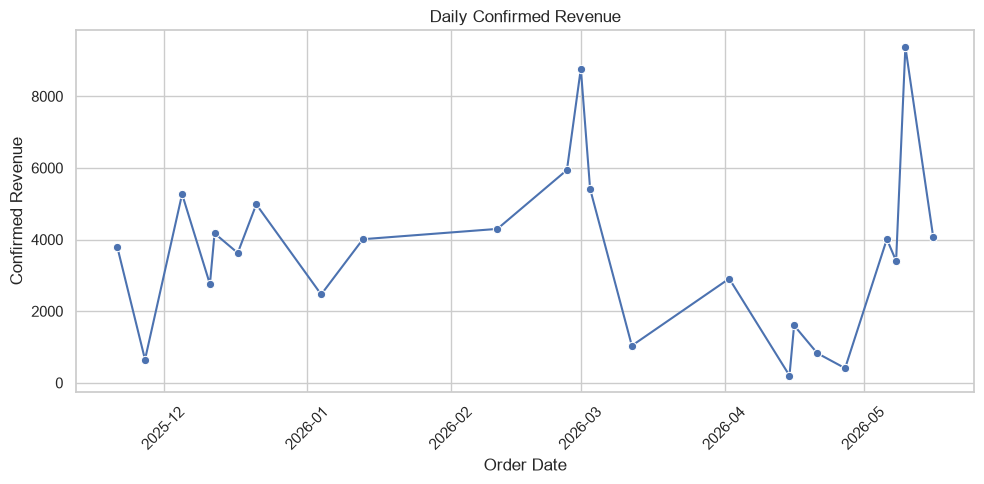

In [19]:
confirmed_sales = confirmed_sales.copy()

confirmed_sales["order_day"] = confirmed_sales["order_date"].dt.floor("D")

daily_sales = confirmed_sales.groupby("order_day").agg(
    daily_revenue=("total_price", "sum"),
    daily_orders=("order_id", "nunique")
).reset_index()

display(daily_sales.head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_sales, x="order_day", y="daily_revenue", marker="o")

plt.title("Daily Confirmed Revenue")
plt.xlabel("Order Date")
plt.ylabel("Confirmed Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Daily Confirmed Revenue

The daily confirmed revenue chart shows that revenue is not consistent across all days. Some days have strong revenue spikes, while other days have low confirmed sales.

This means the business should monitor daily sales performance and investigate high-revenue days to understand what caused the increase, such as larger orders, popular products, or customer behavior.

## Category Performance

This section analyzes which product categories generate the most confirmed revenue.

,category,total_revenue,total_quantity,total_orders
3,Home,25510.71,50,12
1,Clothing,21629.48,37,9
2,Electronics,19633.61,36,10
0,Books,17237.11,54,12


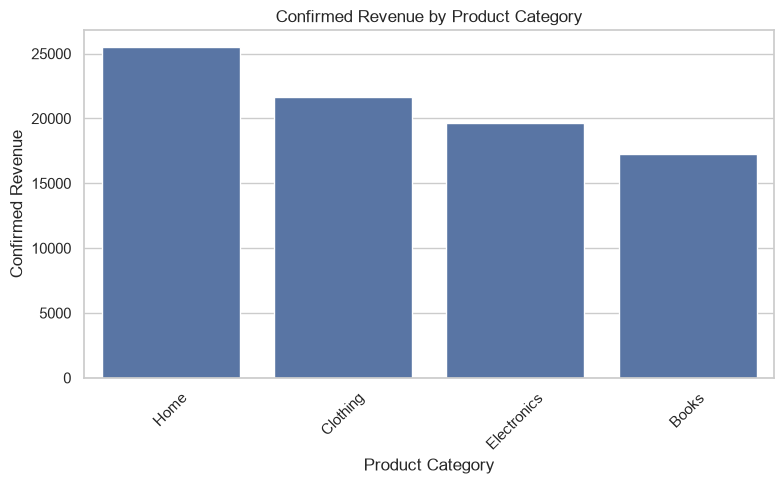

In [20]:
category_revenue = confirmed_sales.groupby("category").agg(
    total_revenue=("total_price", "sum"),
    total_quantity=("quantity", "sum"),
    total_orders=("order_id", "nunique")
).reset_index()

category_revenue = category_revenue.sort_values(by="total_revenue", ascending=False)

display(category_revenue)

plt.figure(figsize=(8, 5))
sns.barplot(data=category_revenue, x="category", y="total_revenue")

plt.title("Confirmed Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Confirmed Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Revenue by Product Category

The Home category generated the highest confirmed revenue, followed by Clothing, Electronics, and Books.

Books had the highest quantity sold, but it did not generate the highest revenue. This suggests that Books may have lower product prices, while Home products may contribute more revenue per sale.

This insight can help the business focus marketing and inventory planning on high-revenue categories such as Home and Clothing.

## Top Product Performance

This section analyzes the top products based on confirmed revenue.

,product_id,product_name,category,total_revenue,total_quantity,total_orders
18,23,Product23,Home,8570.90,13,3
17,22,Product22,Clothing,8448.90,10,3
9,11,Product11,Books,7977.31,11,3
8,10,Product10,Home,6961.05,9,3
15,20,Product20,Clothing,6534.09,9,2
0,1,Product1,Home,5503.12,7,2
20,25,Product25,Electronics,5331.24,6,2
10,14,Product14,Electronics,4882.14,9,3
22,27,Product27,Books,4552.17,21,6
13,18,Product18,Electronics,3361.26,7,2


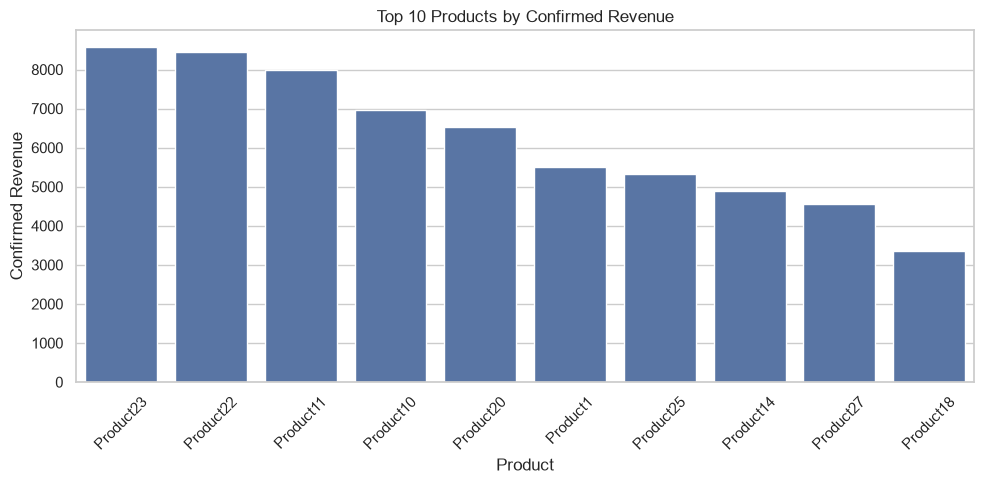

In [21]:
top_products = confirmed_sales.groupby(["product_id", "product_name", "category"]).agg(
    total_revenue=("total_price", "sum"),
    total_quantity=("quantity", "sum"),
    total_orders=("order_id", "nunique")
).reset_index()

top_products = top_products.sort_values(by="total_revenue", ascending=False).head(10)

display(top_products)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x="product_name", y="total_revenue")

plt.title("Top 10 Products by Confirmed Revenue")
plt.xlabel("Product")
plt.ylabel("Confirmed Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Top Products by Confirmed Revenue

Product23 generated the highest confirmed revenue, followed by Product22 and Product11. These products are important because they contribute strongly to successful sales.

The results show that the business should focus on keeping top-performing products available in stock and consider promoting them more. Some products may sell higher quantities but generate lower revenue, which means product price and order value also affect performance.

## Customer Spending Analysis

This section analyzes how much confirmed revenue comes from each customer.

,customer_id,first_name,city,total_spent,total_orders,total_quantity
17,85,Customer85,Abu Dhabi,14712.39,2,28
0,21,Customer21,Dubai,9378.07,1,15
15,76,Customer76,Ajman,8169.02,2,10
14,70,Customer70,Ajman,5391.35,2,14
3,30,Customer30,Sharjah,5269.21,1,9
16,80,Customer80,Dubai,4297.40,1,7
5,32,Customer32,Abu Dhabi,4173.45,1,11
6,34,Customer34,Abu Dhabi,4070.52,1,6
2,29,Customer29,Ajman,4009.81,1,11
10,49,Customer49,Ajman,4009.78,1,9


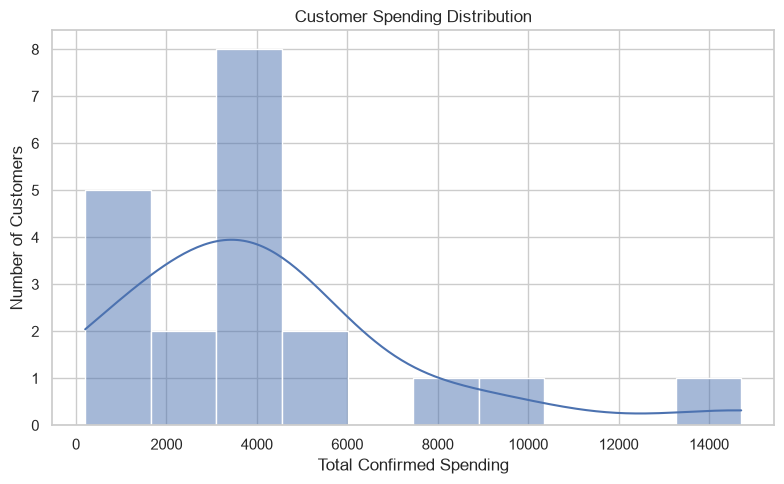

In [22]:
customer_spending = confirmed_sales.groupby(["customer_id", "first_name", "city"]).agg(
    total_spent=("total_price", "sum"),
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum")
).reset_index()

customer_spending = customer_spending.sort_values(by="total_spent", ascending=False)

display(customer_spending.head(10))

plt.figure(figsize=(8, 5))
sns.histplot(customer_spending["total_spent"], bins=10, kde=True)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Confirmed Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Insight: Customer Spending Distribution

The customer spending distribution shows that most customers have moderate confirmed spending, while a smaller number of customers spend much more.

This means the business has a few high-value customers who contribute strongly to confirmed revenue. These customers could be targeted with loyalty offers, personalized promotions, or retention campaigns.

## Order Value Analysis

This section analyzes the value of confirmed orders and checks for unusually high or low order values.

,order_id,order_value,order_date,customer_id,city
0,1,2467.21,2026-01-04 17:14:47.555098,25,Sharjah
1,12,4982.77,2025-12-21 17:14:47.555136,70,Ajman
2,15,4009.78,2026-01-13 17:14:47.555141,49,Ajman
3,20,9378.07,2026-05-10 17:14:47.555150,21,Dubai
4,22,8771.38,2026-03-01 17:14:47.555153,85,Abu Dhabi


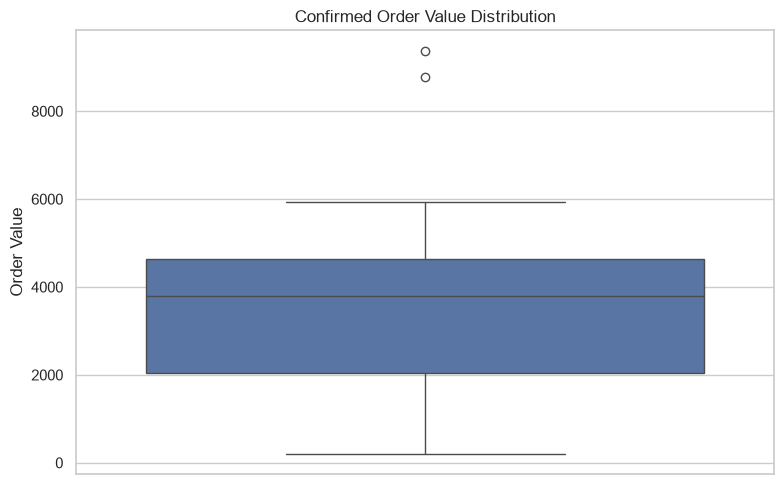

In [23]:
order_values = confirmed_sales.groupby("order_id").agg(
    order_value=("total_price", "sum"),
    order_date=("order_date", "first"),
    customer_id=("customer_id", "first"),
    city=("city", "first")
).reset_index()

display(order_values.head())

plt.figure(figsize=(8, 5))
sns.boxplot(data=order_values, y="order_value")

plt.title("Confirmed Order Value Distribution")
plt.ylabel("Order Value")
plt.tight_layout()
plt.show()

### Insight: Order Value Distribution

The confirmed order value distribution shows that most orders are within a moderate range, while a few orders have much higher values.

These high-value orders may come from customers buying multiple items or higher-priced products. The business should review these orders because they can strongly influence total revenue and average order value.

## Final EDA Findings

The deep exploratory analysis shows that confirmed revenue is much lower than raw total revenue because many orders are cancelled, pending, failed, or refunded. Therefore, confirmed sales should be used for accurate business analysis.

The daily revenue trend shows that confirmed revenue changes across different days, with some strong revenue spikes and some low-sales days. This means the business should monitor daily sales patterns and investigate what causes high-performing days.

The Home category generated the highest confirmed revenue, followed by Clothing, Electronics, and Books. Although Books had high quantity sold, it did not generate the highest revenue, which suggests that product price affects revenue performance.

The top product analysis shows that Product23, Product22, and Product11 are the strongest products by confirmed revenue. These products should be prioritized for stock planning and marketing.

The customer spending distribution shows that most customers spend a moderate amount, while a few customers spend much more. These high-value customers could be targeted with loyalty offers or personalized promotions.

The order value distribution shows that most confirmed orders fall within a normal range, but a few high-value orders strongly affect total revenue and average order value.

Overall, the analysis shows that the business should focus on confirmed successful sales, high-revenue categories, top-performing products, and high-value customers when building the analytics dashboard.